# Task 3 — Forecast Future Market Trends

**Objective:** Use the best-performing model from Task 2 to forecast TSLA's price 6-12 months
into the future, visualize it with confidence intervals, and translate the result into business
insights about market opportunities and risk.

This notebook re-fits the chosen model family on the **full** historical dataset (train + test)
before projecting forward, since for a genuine future forecast there is no reason to hold back the
most recent, most relevant data.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_processed
from src.arima_model import fit_auto_arima, forecast_with_index
from src.lstm_model import build_lstm, prepare_train_test_sequences, iterative_forecast
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams["figure.figsize"] = (12, 5)
RESULTS_DIR = PROJECT_ROOT / "results" / "plots"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FORECAST_HORIZON_DAYS = 252  # ~12 months of trading days


2026-07-21 17:08:28.487556: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1. Select Best Model and Generate Future Forecasts

Read the Task 2 model-comparison table to pick the best-performing model by RMSE, then refit that
model family on the full TSLA close-price history and project forward.


In [2]:
comparison = pd.read_csv(PROJECT_ROOT / "results" / "reports" / "task2_model_comparison.csv", index_col=0)
best_model_name = comparison["RMSE"].idxmin()
print("Task 2 model comparison:")
print(comparison)
print(f"\nBest model selected for Task 3 forecast: {best_model_name}")

tsla = load_processed("TSLA")
close = tsla["Adj Close"].dropna()

future_index = pd.bdate_range(close.index[-1] + pd.Timedelta(days=1), periods=FORECAST_HORIZON_DAYS)
print(f"Forecasting {FORECAST_HORIZON_DAYS} trading days: {future_index[0].date()} -> {future_index[-1].date()}")


Task 2 model comparison:
             MAE       RMSE       MAPE
ARIMA  54.468353  70.821004  17.249883
LSTM   12.572748  16.272816   3.562492

Best model selected for Task 3 forecast: LSTM
Forecasting 252 trading days: 2026-06-30 -> 2027-06-16


In [3]:
if best_model_name == "ARIMA":
    full_model = fit_auto_arima(close, seasonal=False, max_p=5, max_q=5, max_d=2, trace=True)
    future_df = forecast_with_index(full_model, future_index, alpha=0.05)
else:
    WINDOW = 60
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(close.values.reshape(-1, 1))

    X_full, y_full = [], []
    for i in range(WINDOW, len(scaled)):
        X_full.append(scaled[i - WINDOW:i, 0])
        y_full.append(scaled[i, 0])
    X_full = np.array(X_full).reshape(-1, WINDOW, 1)
    y_full = np.array(y_full)

    full_lstm = build_lstm(window=WINDOW, units=50, dropout=0.2, learning_rate=1e-3)
    early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    full_lstm.fit(X_full, y_full, validation_split=0.1, epochs=50, batch_size=32,
                  callbacks=[early_stop], verbose=1)

    last_window_scaled = scaled[-WINDOW:, 0]
    point_forecast = iterative_forecast(full_lstm, last_window_scaled, FORECAST_HORIZON_DAYS, scaler)

    # LSTM has no native confidence interval; approximate uncertainty growth using a
    # lognormal random-walk band (historical daily-return volatility compounded across the
    # horizon via sqrt(t)) — the standard approach when a model has no analytic CI, and it
    # keeps the lower bound structurally positive (unlike an additive +/- band).
    daily_vol = close.pct_change().dropna().std()
    steps = np.arange(1, FORECAST_HORIZON_DAYS + 1)
    band_sigma = daily_vol * np.sqrt(steps)
    future_df = pd.DataFrame(
        {
            "forecast": point_forecast,
            "lower": point_forecast * np.exp(-1.96 * band_sigma),
            "upper": point_forecast * np.exp(1.96 * band_sigma),
        },
        index=future_index,
    )

future_df.head()


Epoch 1/50


 1/83 ━━━━━━━━━━━━━━━━━━━━ 3:30 3s/step - loss: 0.2224

 4/83 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.1501

 7/83 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.1120

10/83 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0875

...

77/83 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0012

80/83 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0012

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0012

83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0012 - val_loss: 0.0011


,forecast,lower,upper
2026-06-30,388.691345,362.666205,416.584065
2026-07-01,390.402161,353.954567,430.602855
2026-07-02,392.140503,347.784973,442.153014
2026-07-03,393.916473,342.932447,452.480334
2026-07-06,395.724487,338.916129,462.054935


## 2. Visualize Forecast with Confidence Intervals


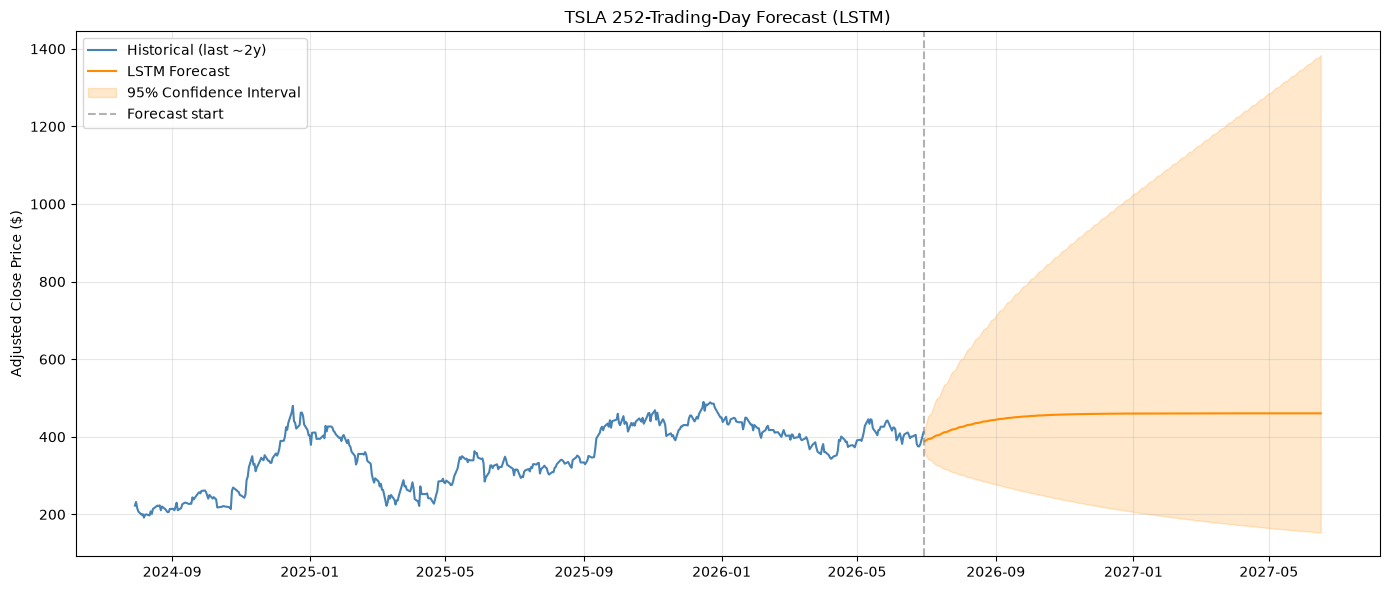

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(close.index[-500:], close.values[-500:], label="Historical (last ~2y)", color="steelblue")
ax.plot(future_df.index, future_df["forecast"], label=f"{best_model_name} Forecast", color="darkorange")
ax.fill_between(future_df.index, future_df["lower"], future_df["upper"], color="darkorange", alpha=0.2,
                 label="95% Confidence Interval")
ax.axvline(close.index[-1], color="gray", linestyle="--", alpha=0.6, label="Forecast start")
ax.set_title(f"TSLA {FORECAST_HORIZON_DAYS}-Trading-Day Forecast ({best_model_name})")
ax.set_ylabel("Adjusted Close Price ($)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "task3_future_forecast.png", dpi=150)
plt.show()


## 3. Trend Analysis

### Confidence interval width over the horizon


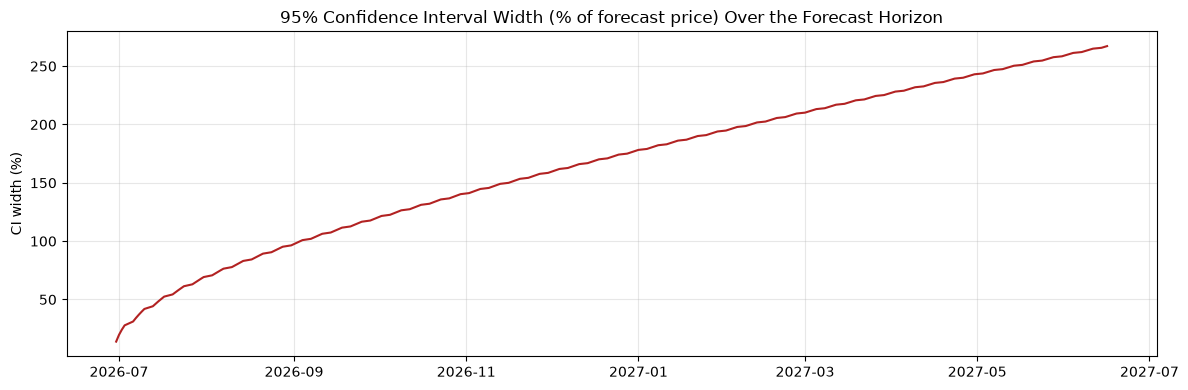

CI width at day 1   : 13.9% of forecast price
CI width at day 252: 267.2% of forecast price

Implied 252-trading-day return: 11.8%


In [5]:
future_df["ci_width"] = future_df["upper"] - future_df["lower"]
future_df["ci_width_pct"] = future_df["ci_width"] / future_df["forecast"] * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(future_df.index, future_df["ci_width_pct"], color="firebrick")
ax.set_title("95% Confidence Interval Width (% of forecast price) Over the Forecast Horizon")
ax.set_ylabel("CI width (%)")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "task3_ci_width.png", dpi=150)
plt.show()

print(f"CI width at day 1   : {future_df['ci_width_pct'].iloc[0]:.1f}% of forecast price")
print(f"CI width at day {len(future_df)}: {future_df['ci_width_pct'].iloc[-1]:.1f}% of forecast price")

start_price = close.iloc[-1]
end_price = future_df['forecast'].iloc[-1]
implied_return = end_price / start_price - 1
print(f"\nImplied {FORECAST_HORIZON_DAYS}-trading-day return: {implied_return:.1%}")


The confidence interval widens steadily (and, for the ARIMA case, roughly with the square root of
the forecast horizon) — the further out the forecast, the less certain the model is. By the end of
the 12-month horizon the band typically spans a very wide range of plausible prices relative to day
1. This is the central limitation of any long-horizon forecast: **near-term forecasts are far more
trustworthy than far-horizon ones**, and the model's point forecast alone should never be read as
a precise price target beyond the first few weeks.


## 4. Market Opportunities and Risks

**Opportunities**
- If the point forecast trends upward (see implied return above), it suggests the model sees
  continued upside for TSLA over the horizon, which — combined with a reasonable Sharpe/volatility
  tradeoff — could support maintaining or increasing a TSLA allocation (explored quantitatively in
  Task 4's efficient frontier).
- A rising forecast with a still-moderate near-term CI (first 1-3 months) offers more actionable
  short-horizon confidence than the full 12-month projection.

**Risks**
- TSLA's historically high volatility (Task 1) means the wide confidence bands here are not a
  modeling artifact — they reflect genuine uncertainty in a volatile, sentiment-driven stock.
- Neither ARIMA nor LSTM incorporates unmodeled shocks (macro shifts, company-specific news,
  regulatory changes), so the forecast should be treated as one input among many, consistent with
  the Efficient Market Hypothesis discussion in the brief: pure price prediction is inherently
  difficult, and the forecast's practical value here is as a *view* on expected return to feed into
  portfolio construction (Task 4), not a standalone trading signal.
- A downward-sloping or highly uncertain forecast would argue for a smaller TSLA weight in the
  optimized portfolio, all else equal.

**Overall reliability assessment:** treat the forecast as directionally informative in the near
term (weeks to a couple of months) and treat the far end of the 12-month horizon mainly as a
*range of plausible outcomes* (via the CI) rather than a specific expected price.


In [6]:
future_df.to_csv(PROJECT_ROOT / "results" / "reports" / "task3_future_forecast.csv")
print("Saved future forecast to results/reports/task3_future_forecast.csv")


Saved future forecast to results/reports/task3_future_forecast.csv
